In [10]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

In [11]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [26]:
df = pd.read_csv('spam.csv', encoding='latin-1')

# Keep required columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert labels
df['label'] = df['label'].map({'ham':0, 'spam':1})

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [39]:
stop_words = set(stopwords.words('english'))

def preprocess(text):
    text = str(text).lower()
    text = re.sub('[^a-zA-Z]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return ' '.join(words)

df['message'] = df['message'].apply(preprocess)

print(df.head())

# User-requested Perceptron code
from sklearn.linear_model import Perceptron

# Instantiate the Perceptron model
perceptron_model = Perceptron(random_state=42)

# To train the Perceptron model, you would typically use:
# perceptron_model.fit(X_train, y_train)

# To make predictions, you would typically use:
# perceptron_predictions = perceptron_model.predict(X_test)

# To evaluate accuracy, you would typically use:
# from sklearn.metrics import accuracy_score
# perceptron_acc = accuracy_score(y_test, perceptron_predictions)
# print("Perceptron Accuracy:", perceptron_acc)

   label                                            message
0      0  go jurong point crazy available bugis n great ...
1      0                            ok lar joking wif u oni
2      1  free entry wkly comp win fa cup final tkts st ...
3      0                u dun say early hor u c already say
4      0             nah think goes usf lives around though


In [28]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df['message'])
y = df['label']

print(X.shape)

(5572, 5000)


In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [31]:
svm = SVC(kernel='linear')
svm.fit(X_train, y_train)

SVC(kernel='linear')

In [32]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

KNeighborsClassifier()

In [47]:
from sklearn.tree import DecisionTreeClassifier

dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [40]:
perceptron_model.fit(X_train, y_train)

Perceptron(random_state=42)

In [33]:
lr_pred = lr.predict(X_test)
svm_pred = svm.predict(X_test)
knn_pred = knn.predict(X_test)

In [48]:
dt_pred = dt_classifier.predict(X_test)

In [41]:
perceptron_pred = perceptron_model.predict(X_test)

In [42]:
lr_acc = accuracy_score(y_test, lr_pred)
svm_acc = accuracy_score(y_test, svm_pred)
knn_acc = accuracy_score(y_test, knn_pred)
perceptron_acc = accuracy_score(y_test, perceptron_pred)

print("Logistic Regression:", lr_acc)
print("SVM:", svm_acc)
print("KNN:", knn_acc)
print("Perceptron:", perceptron_acc)

Logistic Regression: 0.9542600896860987
SVM: 0.97847533632287
KNN: 0.9201793721973094
Perceptron: 0.9739910313901345


In [49]:
dt_acc = accuracy_score(y_test, dt_pred)
print("Decision Tree:", dt_acc)

Decision Tree: 0.95695067264574


In [43]:
print("Logistic Regression\n", classification_report(y_test, lr_pred))
print("SVM\n", classification_report(y_test, svm_pred))
print("KNN\n", classification_report(y_test, knn_pred))
print("Perceptron\n", classification_report(y_test, perceptron_pred))

Logistic Regression
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       965
           1       0.95      0.69      0.80       150

    accuracy                           0.95      1115
   macro avg       0.95      0.84      0.89      1115
weighted avg       0.95      0.95      0.95      1115

SVM
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.86      0.91       150

    accuracy                           0.98      1115
   macro avg       0.98      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115

KNN
               precision    recall  f1-score   support

           0       0.92      1.00      0.96       965
           1       1.00      0.41      0.58       150

    accuracy                           0.92      1115
   macro avg       0.96      0.70      0.77      1115
weighted avg       0.93      0.92      0.91

In [50]:
print("Decision Tree\n", classification_report(y_test, dt_pred))

Decision Tree
               precision    recall  f1-score   support

           0       0.97      0.98      0.98       965
           1       0.85      0.82      0.84       150

    accuracy                           0.96      1115
   macro avg       0.91      0.90      0.91      1115
weighted avg       0.96      0.96      0.96      1115



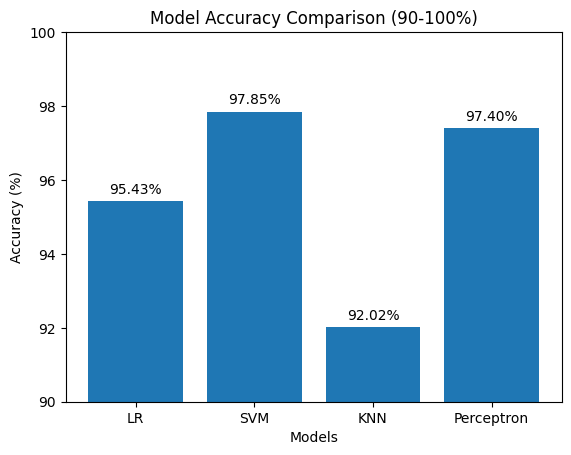

In [44]:
import matplotlib.pyplot as plt

models = ['LR', 'SVM', 'KNN', 'Perceptron']
scores = [lr_acc*100, svm_acc*100, knn_acc*100, perceptron_acc*100]

plt.bar(models, scores)

plt.ylim(90, 100)  # Limit graph

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison (90-100%)")

# Show values on bars
for i, v in enumerate(scores):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.show()

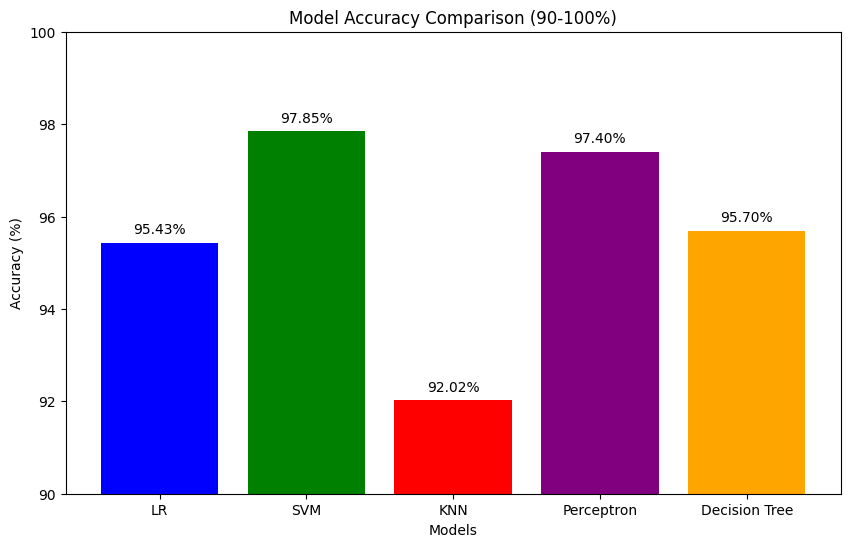

In [51]:
models.append('Decision Tree')
scores.append(dt_acc*100)

plt.figure(figsize=(10, 6))
plt.bar(models, scores, color=['blue', 'green', 'red', 'purple', 'orange'])

plt.ylim(90, 100)

plt.xlabel("Models")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy Comparison (90-100%)")

for i, v in enumerate(scores):
    plt.text(i, v + 0.2, f"{v:.2f}%", ha='center')

plt.show()

In [37]:
def predict_spam(text):
    text = preprocess(text)
    text = vectorizer.transform([text])
    result = lr.predict(text)
    return "Spam" if result[0] == 1 else "Not Spam"

print(predict_spam("Congratulations! You won 1 lakh rupees"))

Not Spam


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Dummy actual and predicted values
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0.0, 2, 8])

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_true, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

# Calculate Mean Squared Error (MSE)
mse = mean_squared_error(y_true, y_pred)
print(f"Mean Squared Error (MSE): {mse:.2f}")

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Mean Absolute Error (MAE): 0.50
Mean Squared Error (MSE): 0.38
Root Mean Squared Error (RMSE): 0.61
